# Nigeria Climate Analysis (2015-2026)
**Data source:** NASA POWER (Prediction of Worldwide Energy Resources)

**Objective:** Profile temperature, precipitation, and humidity patterns in Nigeria to inform COP32 policy recommendations.

**Data Loading & Initial Exploration:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/nigeria.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


**Missing values report:**

In [2]:
print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)

missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent.round(2)
})

print(missing_report[missing_report['Missing Count'] > 0])

if missing_report[missing_report['Missing Count'] > 0].empty:
    print("\n✅ No missing values found!")

MISSING VALUES REPORT
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

✅ No missing values found!


**Distribution overview:**

In [3]:
print("\n" + "=" * 50)
print("DISTRIBUTION OVERVIEW")
print("=" * 50)

key_vars = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
print(df[key_vars].describe().round(2))


DISTRIBUTION OVERVIEW
           T2M  T2M_MAX  T2M_MIN  PRECTOTCORR     RH2M
count  4108.00  4108.00  4108.00      4108.00  4108.00
mean     26.66    28.91    24.89         4.21    85.24
std       1.12     1.29     1.40         7.27     5.45
min      21.12    25.26    15.17         0.00    54.40
25%      25.72    27.92    24.10         0.33    83.93
50%      26.82    28.99    25.10         1.84    86.35
75%      27.54    29.91    25.86         5.20    88.50
max      29.29    32.88    27.79       166.10    93.79


In [4]:
df = df.replace(-999, np.nan)
df['Country'] = 'nigeria'
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month

print(f"nigeria data loaded: {df.shape[0]} rows")

nigeria data loaded: 4108 rows


In [5]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
print("\nOutliers:")
for col in weather_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (abs(z_scores) > 3).sum()
    print(f"{col}: {outliers}")


Outliers:
T2M: 10
T2M_MAX: 1
T2M_MIN: 68
PRECTOTCORR: 75
RH2M: 128
WS2M: 5
WS2M_MAX: 10


**Average Temperature by Month:**

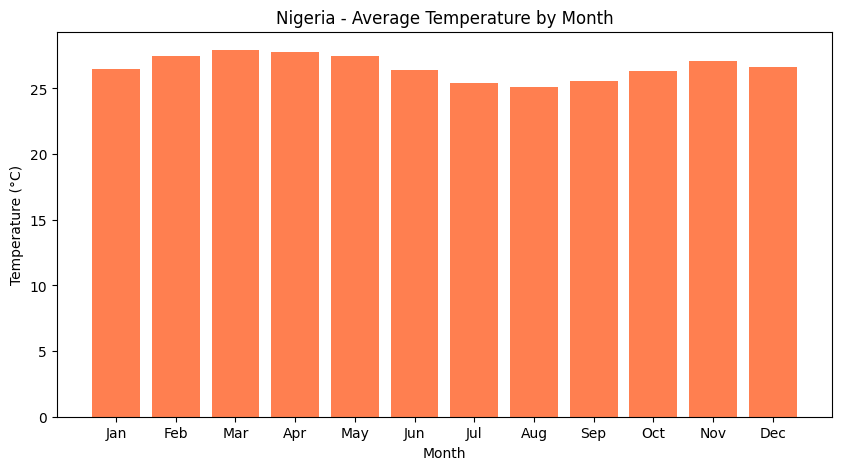

Warmest: Month 3 (27.9°C)
Coolest: Month 8 (25.1°C)


In [6]:
monthly_avg = df.groupby('Month')['T2M'].mean()
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='coral')
plt.title('Nigeria - Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()
print(f"Warmest: Month {monthly_avg.idxmax()} ({monthly_avg.max():.1f}°C)")
print(f"Coolest: Month {monthly_avg.idxmin()} ({monthly_avg.min():.1f}°C)")

### Temperature by Month 
**What it shows:** Average monthly temperatures (Jan-Dec)

**Key findings:**
- High year-round temperatures (25°C - 27.4°C)
- Warmest: March (27.4°C)
- Coolest: August (25.0°C)

**Why matters for COP32:**
- Nigeria is consistently hot, no cool season for relief
- Heat stress is chronic, not episodic
- Cooling infrastructure and heat-health planning needed year-round

**Correlation Heatmap:**

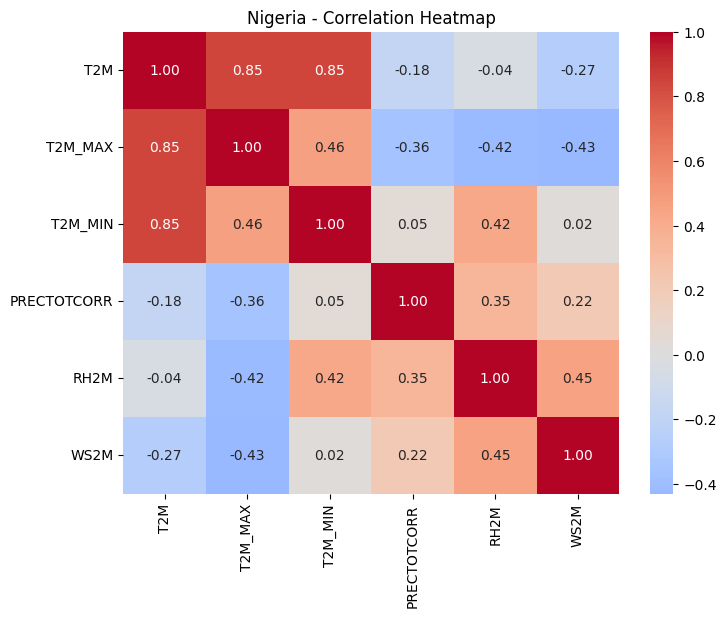

In [7]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Nigeria - Correlation Heatmap')
plt.show()

### Correlation Heatmap
**What it shows:** Relationships between weather variables

**Key findings:**
- Strong positive correlations: T2M with T2M_MAX (0.85) and T2M_MIN (0.85)
- Weak negative correlation: Temperature vs Precipitation (-0.18)
- Humidity correlates moderately with T2M_MIN (0.42) and WS2M (0.45)

**Why matters for COP32:**
- Unlike Kenya/Ethiopia, no strong heat-humidity negative correlation
- Hot days not necessarily dry days, humidity remains high
- Heat stress is humid heat (more dangerous than dry heat for human health)

**Daily Precipitation:**

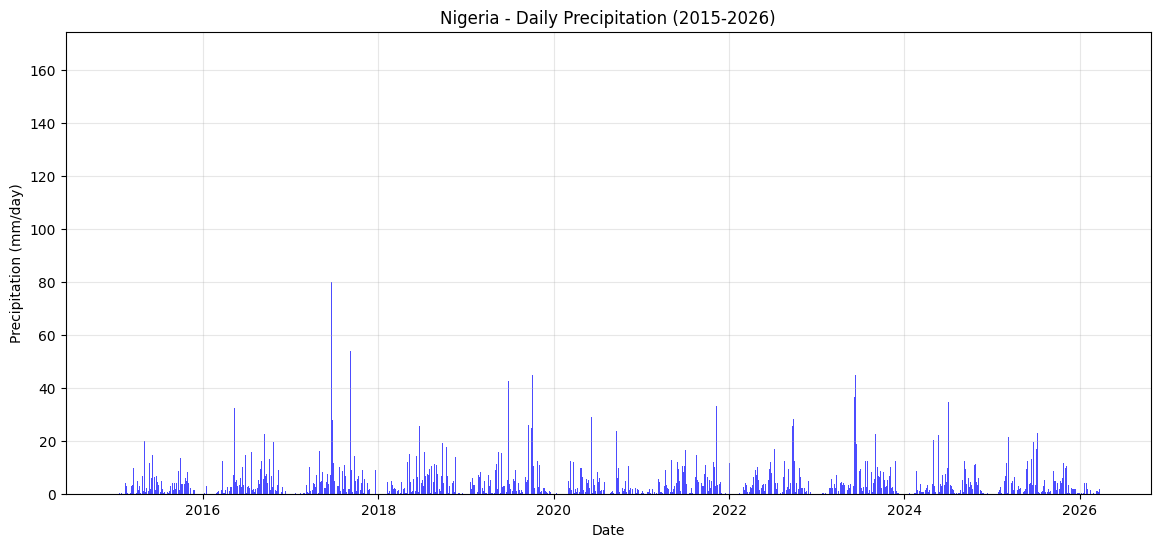

In [8]:
monthly_rain = df.groupby('Date')['PRECTOTCORR'].sum()
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue', alpha=0.7)
plt.title('Nigeria - Daily Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, alpha=0.3)
plt.show()

### Daily Precipitation (Time Series)
**What it shows:** Rainfall patterns 2015-2026

**Key findings:**
- Very high precipitation events (up to 160 mm/day)
- Dense clusters of rain (wet seasons visible)
- Extreme flood events frequent

**Why matters for COP32:**
- Nigeria is the wettest country in the study (4.21 mm/day average)
- Flooding is the primary climate disaster
- Early warning systems and flood infrastructure urgently needed

**Temperature vs Humidity:**

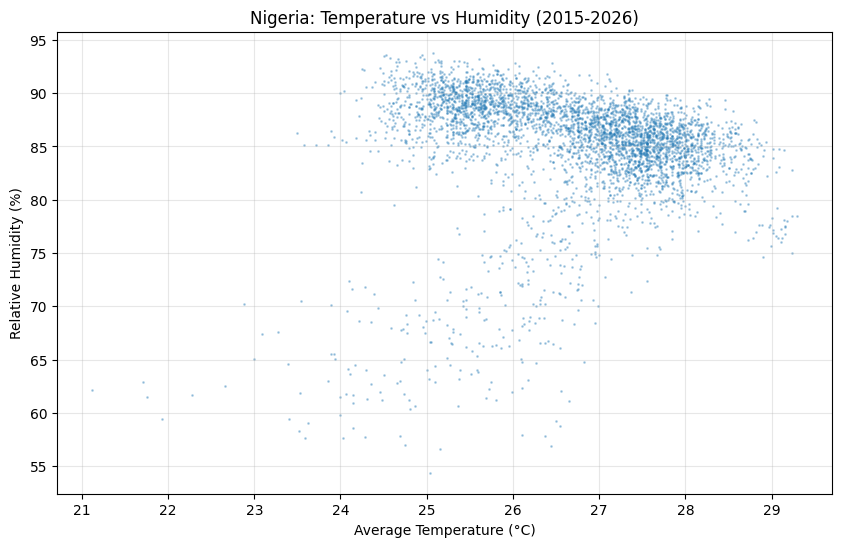

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Nigeria: Temperature vs Humidity (2015-2026)')
plt.grid(True, alpha=0.3)
plt.show()

### Temperature vs Humidity (Scatter Plot)
**What it shows:** Relationship between temperature and humidity

**Key findings:**
- Scattered pattern, no strong relationship
- Humidity stays relatively high across temperature range
- Most points clustered between 23-28°C and 70-90% humidity

**Why matters for COP32:**
- Confirms humid heat environment
- Wet-bulb temperature risk (humans cannot cool via sweat)
- Labor productivity and health at risk

**Temperature Range vs Wind Speed:**

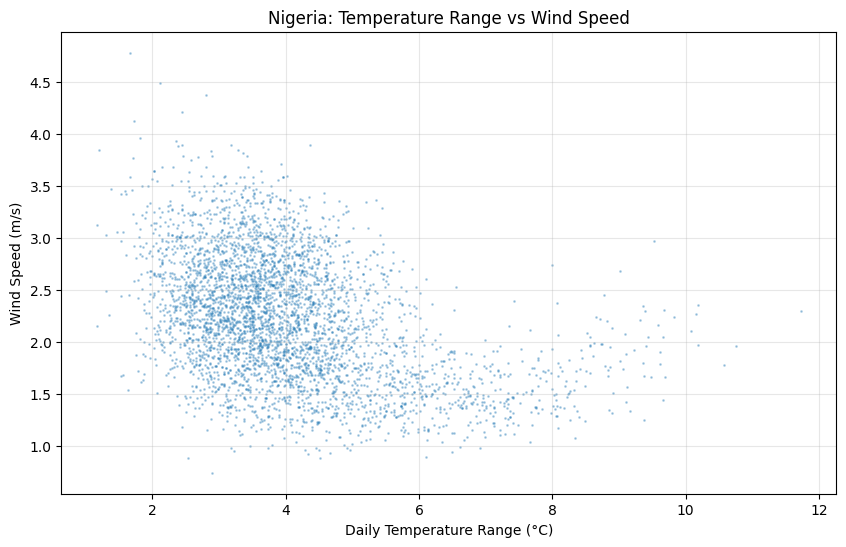

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
plt.xlabel('Daily Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Nigeria: Temperature Range vs Wind Speed')
plt.grid(True, alpha=0.3)
plt.show()

### Temperature Range vs Wind Speed (Scatter Plot)
**What it shows:** Daily temperature fluctuation vs wind

**Key findings:**
- Weak negative correlation
- No strong pattern

**Why matters for COP32:**
- Wind not a primary climate stressor for Nigeria
- Focus should remain on flood and humid heat risks

**Precipitation Distribution:**

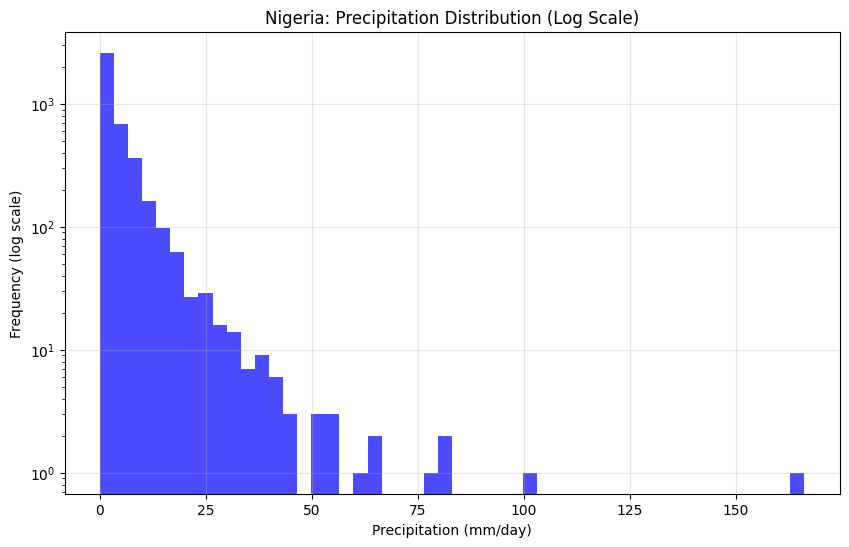

In [11]:
import numpy as np
plt.figure(figsize=(10, 6))
plt.hist(df['PRECTOTCORR'], bins=50, alpha=0.7, color='blue')
plt.yscale('log')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Nigeria: Precipitation Distribution (Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

### Precipitation Distribution (Log Scale Histogram)
**What it shows:** Distribution of daily rainfall amounts

**Key findings:**
- Highly skewed distribution
- Most days: 0-10 mm
- Long tail of extreme events up to 150+ mm

**Why matters for COP32:**
- "Average" rainfall (4.21 mm/day) hides extreme flood risk
- Infrastructure must handle rare but catastrophic events
- Loss and damage accounting needed for flood disasters

**Bubble size:**

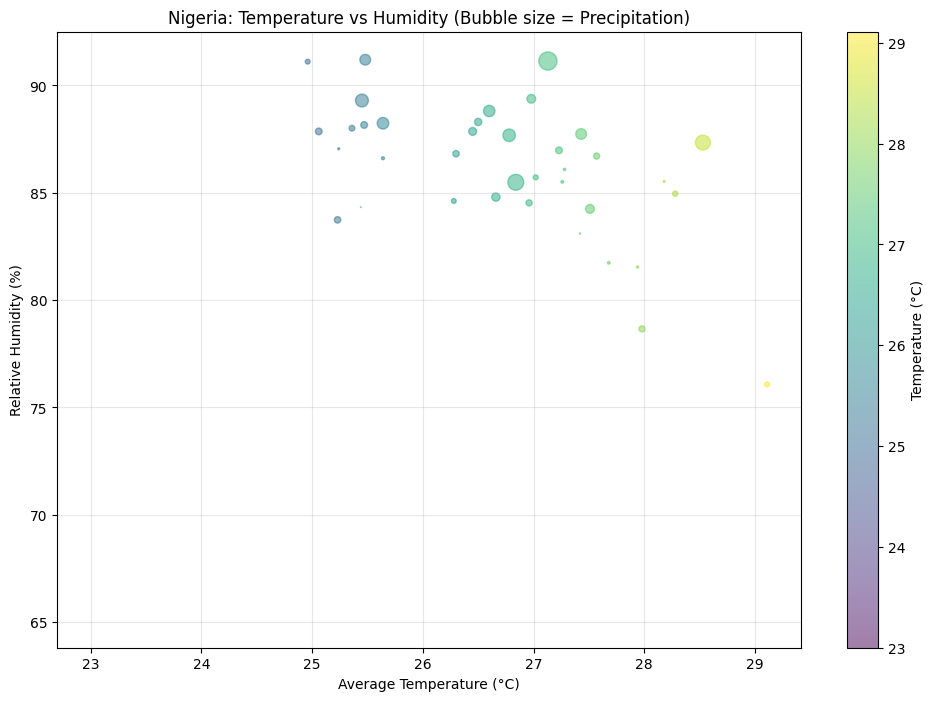

In [12]:
sample = df.iloc[::100, :]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(sample['T2M'], sample['RH2M'], 
                      s=sample['PRECTOTCORR']*10,  # bubble size = precipitation
                      alpha=0.5, c=sample['T2M'], cmap='viridis')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Nigeria: Temperature vs Humidity (Bubble size = Precipitation)')
plt.grid(True, alpha=0.3)
plt.show()

### Bubble Chart (Temperature vs Humidity, Size = Precipitation)
**What it shows:** Heavy rain occurs across temperature range

**Key findings:**
- Large bubbles (heavy rain) at various temperatures
- No clear temperature-rainfall pattern
- High humidity persists regardless of rainfall

**Why matters for COP32:**
- Flood risk exists year-round
- Cannot predict floods by temperature alone
- Need constant monitoring and early warning systems

### Conclusion: Nigeria's COP32 Position

**Key Findings:**
- Consistently hot year-round (25°C - 27.4°C)
- Highest precipitation in the study (4.21 mm/day average, up to 160 mm/day extremes)
- Humid heat environment (no strong heat-dry correlation)
- Extreme flood events frequent and destructive

**COP32 Asks:**
1. Flood early warning systems and climate-resilient infrastructure
2. Humid heat health action plans (wet-bulb temperature monitoring)
3. Loss and damage funding for recurrent flood disasters
4. Climate-resilient housing in flood-prone zones

**Final Statement:**
Nigeria's climate crisis is defined by two simultaneous threats: extreme flooding and humid heat. Unlike dry heat stress in Sudan or water scarcity in Kenya, Nigeria's humid heat is more dangerous for human health, while its flood risk exceeds all other countries in this study. Adaptation finance must address both crises with equal urgency.

In [13]:
# Save cleaned Nigeria data
df.to_csv('../data/nigeria_clean.csv', index=False)
print("✅ Saved: data/nigeria_clean.csv")

✅ Saved: data/nigeria_clean.csv
